# **Mô hình CNN**

Bài tập mẫu

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
import keras
from keras.layers import Conv2D, Dense, MaxPool2D, Flatten, Activation, MaxPooling2D, Dropout
from keras.models import Sequential
from keras import Input
import matplotlib.pyplot as plt

Khởi tạo dữ liệu

In [ ]:
# Đọc dữ liệu MNIST
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
print("Thông tin shape: ")
print("x train: ", x_train.shape)
print("y train: ", y_train.shape)
print("x test: ", x_test.shape)
print("y test: ", y_test.shape)


Thông tin shape: 
x train:  (60000, 28, 28)
y train:  (60000,)
x test:  (10000, 28, 28)
y test:  (10000,)


Xử lý dữ liệu

In [ ]:
so_nhan = 10
input_shape = (28, 28, 1)
x_train = x_train.astype("float32")/255
x_test = x_test.astype("float32")/255

x_train = np.array(x_train)
x_train = x_train.reshape(x_train.shape[0], 28, 28, 1)

x_test = np.array(x_test)
x_test = x_test.reshape(x_test.shape[0], 28, 28, 1)

print(x_train.shape)
print(x_test.shape)

print('So nhan: ', len(np.unique(y_train)))
print('Cac nhan: ', np.unique(y_train))

(60000, 28, 28, 1)
(10000, 28, 28, 1)
So nhan:  10
Cac nhan:  [0 1 2 3 4 5 6 7 8 9]


Trực quan hóa dữ liệu

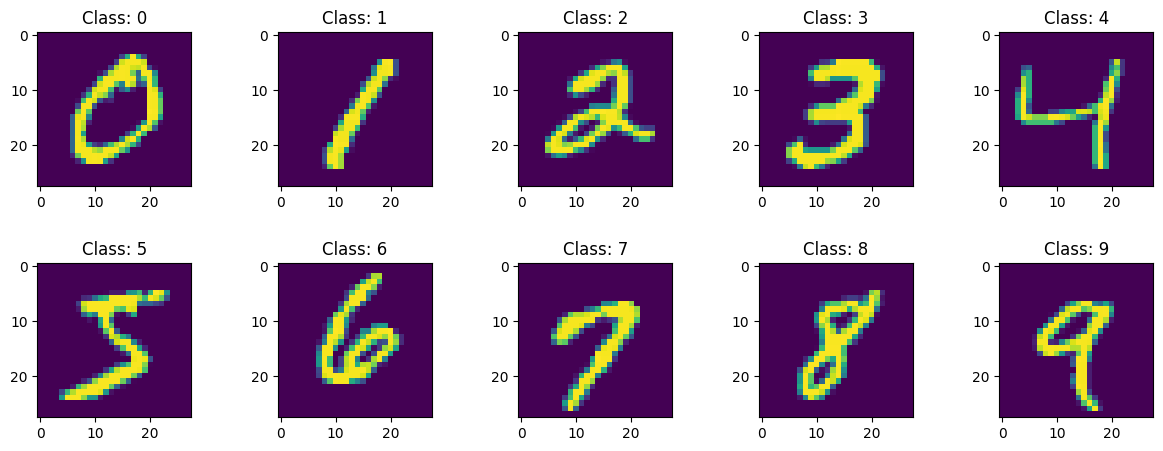

In [ ]:
values, unique_index = np.unique(y_train, return_index="true")

fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(15,5))
ax = axes.ravel()

for index, item in enumerate(unique_index):
    ax[index].imshow(x_train[item])
    ax[index].title.set_text('Class: ' + str(y_train[item]))
plt.subplots_adjust(hspace=0.5)
plt.show()

One hot coding giá trị nhãn

In [ ]:
y_train = keras.utils.to_categorical(y_train, so_nhan)
y_test = keras.utils.to_categorical(y_test, so_nhan)

[[0. 0. 0. ... 1. 0. 0.]
 [0. 0. 1. ... 0. 0. 0.]
 [0. 1. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


Xây dựng mô hình CNN

In [ ]:
model = Sequential()
model.add(Input(shape=input_shape))
model.add(Conv2D(filters=32, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Conv2D(filters=64, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(units=10, activation='softmax'))
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │        16,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,826 (136.04 KB)

 Trainable params: 34,826 (136.04 KB)

 Non-trainable params: 0 (0.00 B)

Huấn luyện mô hình

In [ ]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_fit = model.fit(x_train, y_train, batch_size=128, epochs=5, validation_split=0.1, verbose=1)

Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 37s 82ms/step - accuracy: 0.9948 - loss: 0.0157 - val_accuracy: 0.9880 - val_loss: 0.0438
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 36s 85ms/step - accuracy: 0.9963 - loss: 0.0122 - val_accuracy: 0.9890 - val_loss: 0.0414
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 38s 78ms/step - accuracy: 0.9963 - loss: 0.0110 - val_accuracy: 0.9877 - val_loss: 0.0425
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 35s 63ms/step - accuracy: 0.9969 - loss: 0.0094 - val_accuracy: 0.9882 - val_loss: 0.0452
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 26s 62ms/step - accuracy: 0.9975 - loss: 0.0077 - val_accuracy: 0.9895 - val_loss: 0.0411


Đánh giá mô hình

Độ chính xác

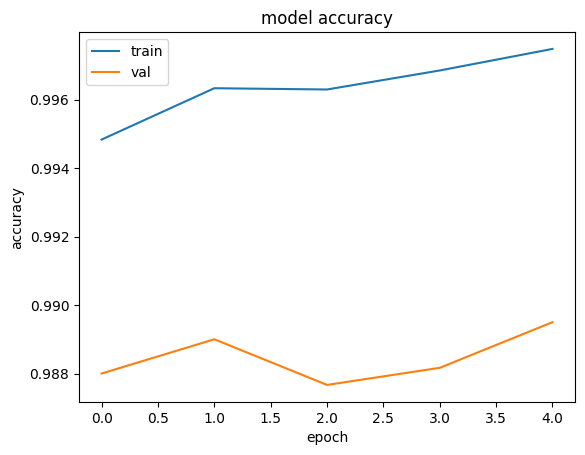

In [ ]:
plt.plot(model_fit.history['accuracy'])
plt.plot(model_fit.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

Độ sai sót

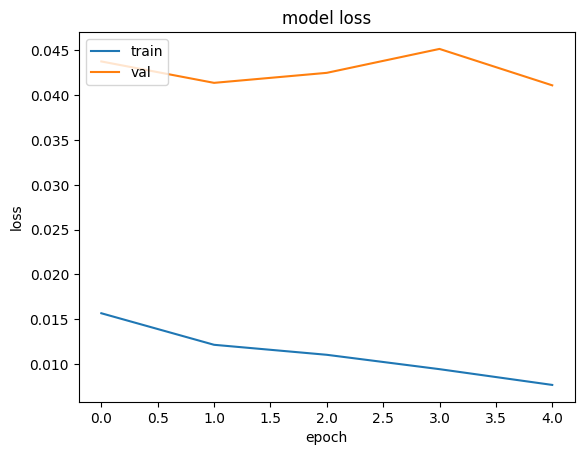

In [ ]:
plt.plot(model_fit.history['loss'])
plt.plot(model_fit.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

Dự báo nhãn cho ảnh

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
7 7


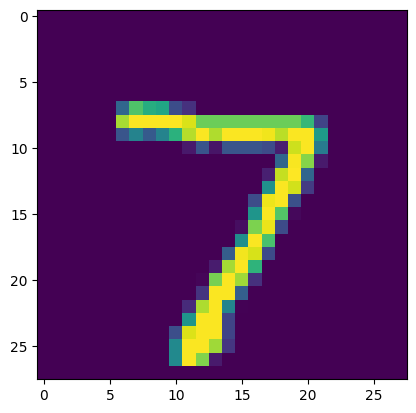

In [ ]:
predict = model.predict(x_test[:1])
print(np.argmax(predict), np.argmax(y_test[0]))
plt.imshow(x_test[:1].reshape(28,28))
plt.show()


In [ ]:
model.save_weights('cnn.weights.h5')

Nạp lại mô hình và tham số

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
[[9.3362739e-12 6.4465312e-12 1.0000000e+00 2.0597167e-15 3.1077387e-16
  1.1411109e-18 1.2946358e-09 1.7096622e-17 4.0178586e-11 7.0602949e-15]]
2 2


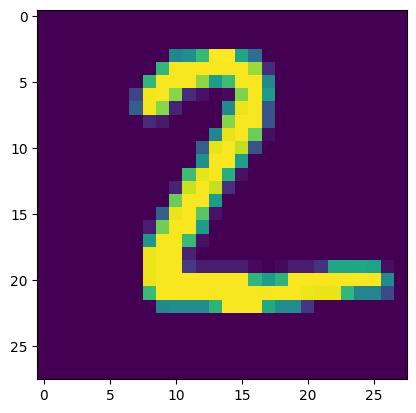

In [ ]:
model = Sequential()
model.add(Input(shape=input_shape))
model.add(Conv2D(filters=32, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Conv2D(filters=64, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(units=10, activation='softmax'))
model.load_weights('cnn.weights.h5')

predict = model.predict(x_test[1:2])
print(predict)
print(np.argmax(predict), np.argmax(y_test[1]))
plt.imshow(x_test[1:2].reshape(28,28))
plt.show()

# **Mô hình CNN nâng cấp**

Khởi tạo dữ liệu

In [ ]:
# Đọc dữ liệu MNIST
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
print("Thông tin shape: ")
print("x train: ", x_train.shape)
print("y train: ", y_train.shape)
print("x test: ", x_test.shape)
print("y test: ", y_test.shape)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Thông tin shape: 
x train:  (60000, 28, 28)
y train:  (60000,)
x test:  (10000, 28, 28)
y test:  (10000,)


Xử lý dữ liệu

In [ ]:
so_nhan = 10
input_shape = (28, 28, 1)
x_train = x_train.astype("float32")/255
x_test = x_test.astype("float32")/255

x_train = np.array(x_train)
x_train = x_train.reshape(x_train.shape[0], 28, 28, 1)

x_test = np.array(x_test)
x_test = x_test.reshape(x_test.shape[0], 28, 28, 1)

print(x_train.shape)
print(x_test.shape)

print('So nhan: ', len(np.unique(y_train)))
print('Cac nhan: ', np.unique(y_train))

(60000, 28, 28, 1)
(10000, 28, 28, 1)
So nhan:  10
Cac nhan:  [0 1 2 3 4 5 6 7 8 9]


In [ ]:
def xay_dung_mo_hinh_cnn():
    mo_hinh = Sequential(name="Mo_hinh_nang_cap")

    # Lớp đầu vào với shape (28, 28, 1)
    mo_hinh.add(Input(shape=(28, 28, 1)))

    # KHỐI TRÍCH XUẤT ĐẶC TRƯNG
    # Lớp 1:
    mo_hinh.add(Conv2D(filters=32, kernel_size=(3, 3), padding='same', name='Lop_Tich_chap_1_1'))
    mo_hinh.add(Activation('relu', name='Lop_Relu_1_1'))

    mo_hinh.add(Conv2D(filters=32, kernel_size=(3, 3), padding='same', name='Lop_Tich_chap_1_2'))
    mo_hinh.add(Activation('relu', name='Lop_Relu_1_2'))

    mo_hinh.add(MaxPooling2D(pool_size=(2, 2), name='Lop_Gop_1'))
    mo_hinh.add(Dropout(rate=0.3, name='Lop_Loai_bo_1'))

    # Lớp 2:
    mo_hinh.add(Conv2D(filters=64, kernel_size=(3, 3), padding='same', name='Lop_Tich_chap_2_1'))
    mo_hinh.add(Activation('relu', name='Lop_Relu_2_1'))

    mo_hinh.add(Conv2D(filters=64, kernel_size=(3, 3), padding='same', name='Lop_Tich_chap_2_2'))
    mo_hinh.add(Activation('relu', name='Lop_Relu_2_2'))

    mo_hinh.add(MaxPooling2D(pool_size=(2, 2), name='Lop_Gop_2'))
    mo_hinh.add(Dropout(rate=0.3, name='Lop_Loai_bo_2'))

    # KHỐI PHÂN LOẠI
    mo_hinh.add(Flatten(name='Flatten'))
    mo_hinh.add(Dense(units=256, name='Dense'))
    mo_hinh.add(Activation('relu', name='ReLU_Dense'))
    mo_hinh.add(Dropout(rate=0.3, name='Loai_bo_Dense'))

    mo_hinh.add(Dense(units=10, activation='softmax', name='Dense_Output_Softmax'))

    return mo_hinh

# Khởi tạo mô hình và in ra cấu trúc
mo_hinh_hoan_chinh = xay_dung_mo_hinh_cnn()
mo_hinh_hoan_chinh.summary()

Model: "Mo_hinh_nang_cap"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Lop_Tich_chap_1_1 (Conv2D)      │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Lop_Relu_1_1 (Activation)       │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Lop_Tich_chap_1_2 (Conv2D)      │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Lop_Relu_1_2 (Activation)       │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Lop_Gop_1 (MaxPooling2D)        │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Lop_Loai_bo_1 (Dropout)         │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Lop_Tich_chap_2_1 (Conv2D)      │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Lop_Relu_2_1 (Activation)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Lop_Tich_chap_2_2 (Conv2D)      │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Lop_Relu_2_2 (Activation)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Lop_Gop_2 (MaxPooling2D)        │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Lop_Loai_bo_2 (Dropout)         │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense (Dense)                   │ (None, 256)            │       803,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ReLU_Dense (Activation)         │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Loai_bo_Dense (Dropout)         │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense_Output_Softmax (Dense)    │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 870,634 (3.32 MB)

 Trainable params: 870,634 (3.32 MB)

 Non-trainable params: 0 (0.00 B)

Huấn luyện mô hình

In [ ]:
mo_hinh_hoan_chinh.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy', # Sử dụng 'sparse' vì nhãn y_train đang là số nguyên (0-9), chưa one-hot encoding
    metrics=['accuracy']
)
so_epoch = 3
kich_thuoc_batch = 128

print("\nBắt đầu quá trình huấn luyện...")
lich_su_huan_luyen = mo_hinh_hoan_chinh.fit(
    x_train,
    y_train,
    batch_size=kich_thuoc_batch,
    epochs=so_epoch,
    validation_split=0.2,
    verbose=1
)

print("\nĐang đánh giá mô hình trên tập kiểm tra (Test set)...")
loss, do_chinh_xac = mo_hinh_hoan_chinh.evaluate(x_test, y_test, verbose=0)

print(f"Độ mất mát (Loss) trên tập test: {loss:.4f}")
print(f"Độ chính xác (Accuracy) trên tập test: {do_chinh_xac * 100:.2f}%")


Bắt đầu quá trình huấn luyện...
Epoch 1/3
375/375 ━━━━━━━━━━━━━━━━━━━━ 121s 318ms/step - accuracy: 0.9096 - loss: 0.2794 - val_accuracy: 0.9783 - val_loss: 0.0706
Epoch 2/3
375/375 ━━━━━━━━━━━━━━━━━━━━ 116s 309ms/step - accuracy: 0.9749 - loss: 0.0838 - val_accuracy: 0.9884 - val_loss: 0.0383
Epoch 3/3
375/375 ━━━━━━━━━━━━━━━━━━━━ 147s 323ms/step - accuracy: 0.9825 - loss: 0.0586 - val_accuracy: 0.9903 - val_loss: 0.0358

Đang đánh giá mô hình trên tập kiểm tra (Test set)...
Độ mất mát (Loss) trên tập test: 0.0295
Độ chính xác (Accuracy) trên tập test: 99.00%


Đánh giá ma trận nhầm lẫn

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step


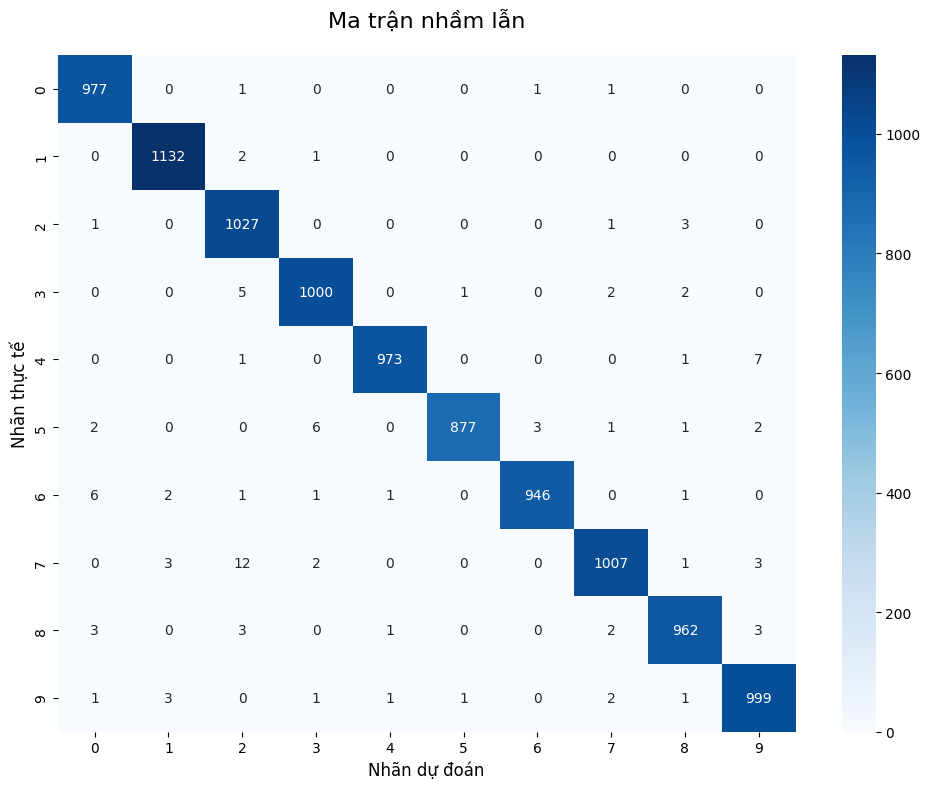

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

y_pred_probs = mo_hinh_hoan_chinh.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=range(10),
    yticklabels=range(10)
)
plt.title('Ma trận nhầm lẫn', fontsize=16, pad=20)
plt.xlabel('Nhãn dự đoán', fontsize=12)
plt.ylabel('Nhãn thực tế', fontsize=12)

plt.tight_layout()
plt.show()

Thử nghiệm trên ảnh thật

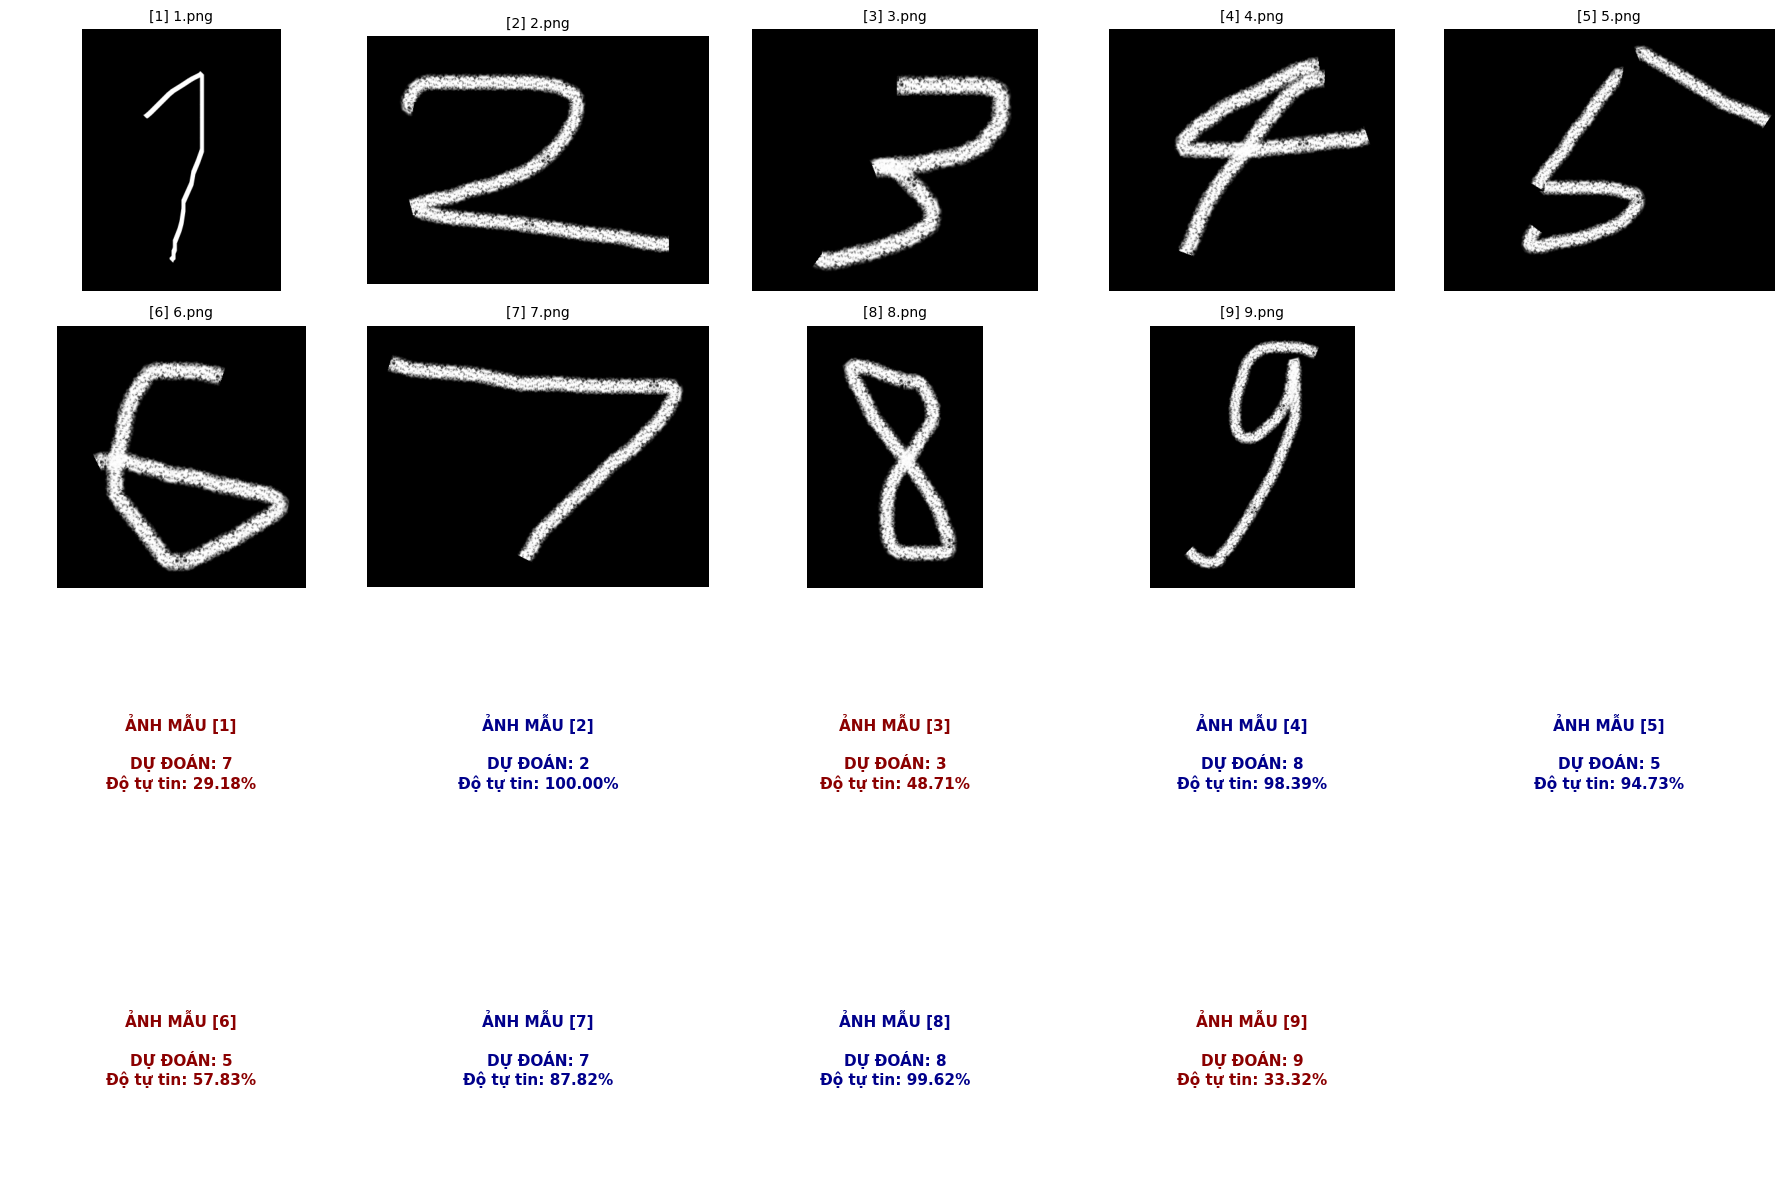

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Định nghĩa đường dẫn đến thư mục chứa ảnh thật trên Colab
thu_muc_anh = '/content/anh_that'

# 2. Kiểm tra thư mục và lấy danh sách tối đa 10 tệp ảnh đầu tiên
dinh_dang_hop_le = ('.png', '.jpg', '.jpeg', '.bmp')
if os.path.exists(thu_muc_anh):
    danh_sach_anh = [f for f in os.listdir(thu_muc_anh) if f.lower().endswith(dinh_dang_hop_le)]
    danh_sach_anh = sorted(danh_sach_anh)[:10]  # Giới hạn lấy tối đa 10 ảnh
else:
    danh_sach_anh = []
    print(f"Lỗi: Không tìm thấy thư mục '{thu_muc_anh}'. Hãy đảm bảo bạn đã tạo thư mục này.")

so_luong_anh = len(danh_sach_anh)

if so_luong_anh == 0:
    print("Thư mục trống hoặc không chứa định dạng ảnh hợp lệ.")
else:
    # Khởi tạo khung vẽ gồm 4 hàng và 5 cột (Tổng cộng 20 ô)
    # Hàng 0 và Hàng 1: Dùng để hiển thị ảnh thật
    # Hàng 2 và Hàng 3: Dùng để hiển thị chữ kết quả dự đoán
    fig, axes = plt.subplots(4, 5, figsize=(18, 12))

    for idx in range(10):
        # Tính toán vị trí tọa độ ô cho ảnh (Hàng 0 cho 5 ảnh đầu, Hàng 1 cho 5 ảnh sau)
        hang_anh = 0 if idx < 5 else 1
        cot_anh = idx % 5
        ax_anh = axes[hang_anh, cot_anh]

        # Tính toán vị trí tọa độ ô cho chữ kết quả (Tương ứng ở Hàng 2 và Hàng 3)
        hang_chu = 2 if idx < 5 else 3
        cot_chu = idx % 5
        ax_chu = axes[hang_chu, cot_chu]

        if idx < so_luong_anh:
            ten_file = danh_sach_anh[idx]
            duong_dan_anh = os.path.join(thu_muc_anh, ten_file)

            # Đọc ảnh gốc bằng OpenCV
            img_bgr = cv2.imread(duong_dan_anh)

            # Chuyển đổi hệ màu để hiển thị chính xác trên matplotlib
            img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

            # Hiển thị ảnh gốc lên khung hình
            ax_anh.imshow(img_rgb)
            ax_anh.set_title(f"[{idx+1}] {ten_file}", fontsize=10)
            ax_anh.axis('off')

            # --- TIỀN XỬ LÝ ẢNH CHO MÔ HÌNH CNN ---
            # Chuyển sang ảnh xám
            img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
            # Thay đổi kích thước về đúng chuẩn 28x28
            img_resized = cv2.resize(img_gray, (28, 28))

            # [LƯU Ý]: Nếu ảnh thật là chữ ĐEN trên giấy TRẮNG, bạn hãy mở dấu '#' ở dòng dưới:
            # img_resized = cv2.bitwise_not(img_resized)

            # Chuẩn hóa ma trận điểm ảnh đầu vào
            img_input = img_resized.astype('float32') / 255.0
            img_input = np.expand_dims(img_input, axis=(0, -1))

            # --- DỰ ĐOÁN KẾT QUẢ ---
            xac_suat_du_doan = mo_hinh_hoan_chinh.predict(img_input, verbose=0)
            lop_du_doan = np.argmax(xac_suat_du_doan)
            do_tu_tin = np.max(xac_suat_du_doan) * 100

            # Hiển thị kết quả bằng dạng văn bản thuần túy (Ẩn viền ô trống)
            ax_chu.text(
                0.5, 0.5,
                f"ẢNH MẪU [{idx+1}]\n\nDỰ ĐOÁN: {lop_du_doan}\nĐộ tự tin: {do_tu_tin:.2f}%",
                fontsize=11,
                ha='center',
                va='center',
                weight='bold',
                color='darkblue' if do_tu_tin > 80 else 'darkred' # Chữ xanh nếu độ tự tin cao, chữ đỏ nếu thấp
            )
            ax_chu.axis('off')

        else:
            # Nếu trong thư mục có ít hơn 10 ảnh, tự động ẩn toàn bộ các ô thừa còn lại
            ax_anh.axis('off')
            ax_chu.axis('off')

    plt.tight_layout()
    plt.show()

Bài tập 3

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
import keras
from keras.layers import Conv2D, Dense, MaxPool2D, Flatten
from keras.models import Sequential
from keras import Input
import matplotlib.pyplot as plt

In [ ]:

# Load the dataset
fashion_mnist = tf.keras.datasets.fashion_mnist
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

print("Train image shape: ", train_images.shape)
print("Train labels shape: ", train_labels.shape)
print("Test image shape: ", test_images.shape)
print("Test label shape: ", test_labels.shape)

Train image shape:  (60000, 28, 28)
Train labels shape:  (60000,)
Test image shape:  (10000, 28, 28)
Test label shape:  (10000,)


Xử lý dữ liệu

In [ ]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler
# CNN Keras yêu cầu đầu vào có 4 chiều:
# (số lượng ảnh, chiều cao, chiều rộng, số kênh màu)
# Đổi kích thước train image và test image sang 4 chiều
so_nhan = len(np.unique(test_labels))
train_images = train_images.astype("float32")/255
test_images = test_images.astype("float32")/255

train_images = np.array(train_images)
train_images = train_images.reshape(train_images.shape[0], 28, 28, 1)

test_images = np.array(test_images)
test_images = test_images.reshape(test_images.shape[0], 28, 28, 1)

print("Train image shape: ", train_images.shape)
print("Train labels shape: ", train_labels.shape)
print("Test image shape: ", test_images.shape)
print("Test label shape: ", test_labels.shape)

print("Các nhãn: ", np.unique(test_labels))
print("Số nhãn: ", so_nhan)

Train image shape:  (60000, 28, 28, 1)
Train labels shape:  (60000,)
Test image shape:  (10000, 28, 28, 1)
Test label shape:  (10000,)
Các nhãn:  [0 1 2 3 4 5 6 7 8 9]
Số nhãn:  10


Mô hình CNN

In [ ]:
# Khai báo mô hình
mo_hinh_bai_3 = Sequential()

# Lớp đầu vào
mo_hinh_bai_3.add(Input(shape=(28,28,1)))

# Lớp ẩn
mo_hinh_bai_3.add(Conv2D(filters=32, kernel_size=(3,3), strides=(1,1), activation='relu'))
mo_hinh_bai_3.add(MaxPool2D(pool_size=(2,2)))
mo_hinh_bai_3.add(Conv2D(filters=64, kernel_size=(3,3), strides=(1,1), activation='relu'))
mo_hinh_bai_3.add(MaxPool2D(pool_size=(2,2)))

# Lớp đầu ra
mo_hinh_bai_3.add(Flatten())

mo_hinh_bai_3.add(Dense(units=10 ,activation='softmax')) #units tương ứng với số nhãn
mo_hinh_bai_3.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │        16,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,826 (136.04 KB)

 Trainable params: 34,826 (136.04 KB)

 Non-trainable params: 0 (0.00 B)

Huấn luyện mô hình

In [ ]:
mo_hinh_bai_3.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
mo_hinh_bai_3_fit = mo_hinh_bai_3.fit(train_images, train_labels, batch_size=128, epochs=2, validation_split=0.1, verbose=1)

Epoch 1/2
422/422 ━━━━━━━━━━━━━━━━━━━━ 52s 117ms/step - accuracy: 0.7778 - loss: 0.6319 - val_accuracy: 0.8455 - val_loss: 0.4291
Epoch 2/2
422/422 ━━━━━━━━━━━━━━━━━━━━ 45s 106ms/step - accuracy: 0.8609 - loss: 0.3952 - val_accuracy: 0.8595 - val_loss: 0.3924


Đánh giá mô hình

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step


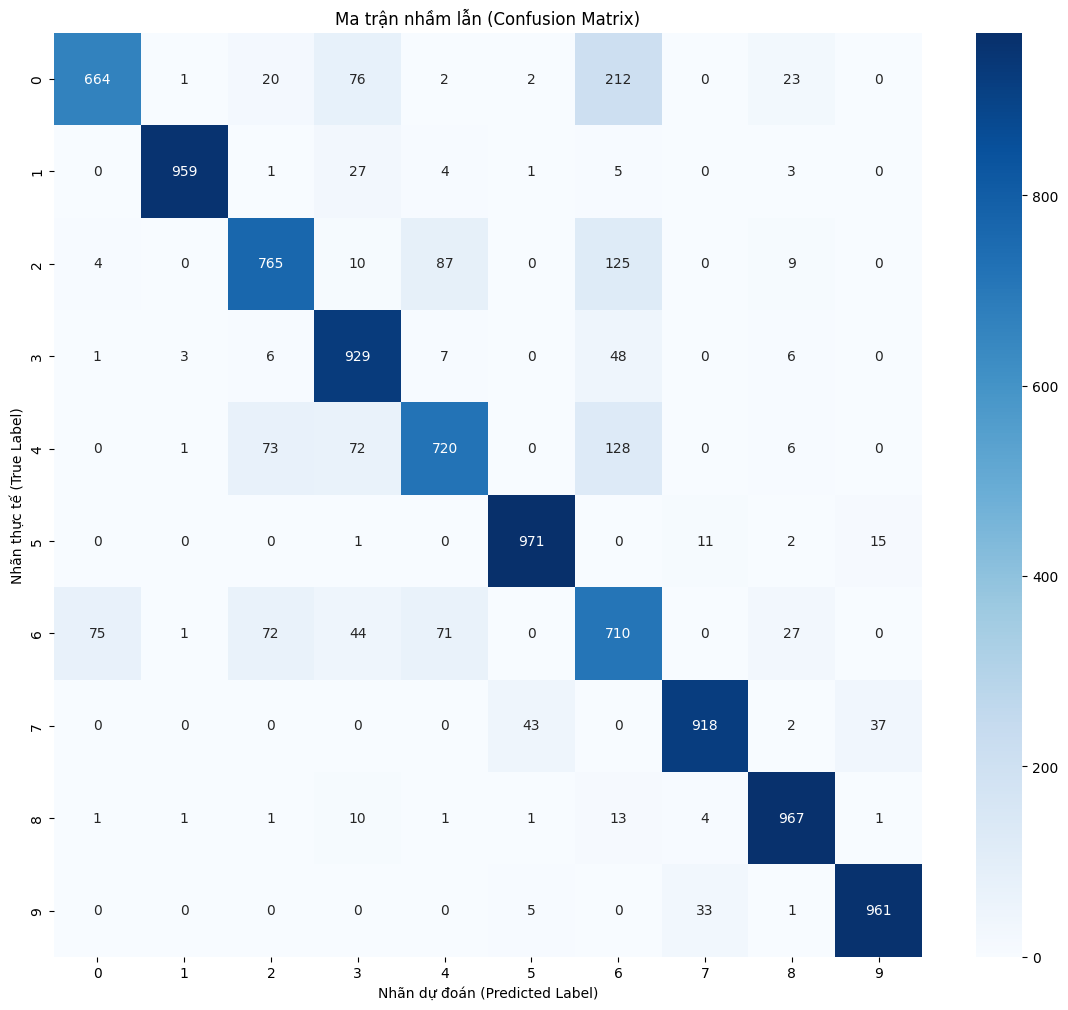

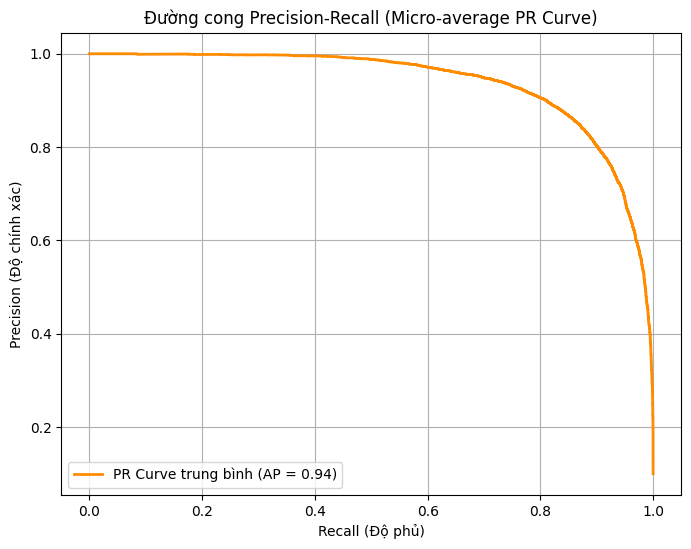

In [ ]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    average_precision_score
)
from sklearn.preprocessing import label_binarize

xac_suat_du_doan = mo_hinh_bai_3.predict(test_images)
nhan_du_doan = np.argmax(xac_suat_du_doan, axis=1)

# Đánh giá: Ma trận nhầm lẫn (Confusion Matrix)
ma_tran = confusion_matrix(test_labels, nhan_du_doan)

plt.figure(figsize=(14, 12))
sns.heatmap(ma_tran, annot=True, fmt='d', cmap='Blues')
plt.title('Ma trận nhầm lẫn (Confusion Matrix)')
plt.xlabel('Nhãn dự đoán (Predicted Label)')
plt.ylabel('Nhãn thực tế (True Label)')
plt.show()
plt.savefig('confusion_matrix.png', bbox_inches='tight', dpi=300)
plt.close()

# Đánh giá: PR Curve (Precision-Recall Curve)
nhan_test_bin = label_binarize(test_labels, classes=range(10))

precision, recall, _ = precision_recall_curve(nhan_test_bin.ravel(), xac_suat_du_doan.ravel())
ap_score = average_precision_score(nhan_test_bin.ravel(), xac_suat_du_doan.ravel())

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='darkorange', lw=2, label=f'PR Curve trung bình (AP = {ap_score:0.2f})')
plt.xlabel('Recall (Độ phủ)')
plt.ylabel('Precision (Độ chính xác)')
plt.title('Đường cong Precision-Recall (Micro-average PR Curve)')
plt.legend(loc="lower left")
plt.grid(True)
plt.show()
plt.savefig('precision_recall_curve.png', bbox_inches='tight', dpi=300)
plt.close()
